# XAI CODE DEMO
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/dev/interpretable-ml-example-notebooks/regression-interpretability.ipynb)

# Regression for Interpretability

* Linear Regression: The coefficients directly show the impact of each feature on the target variable
* Ridge Regression: Similar to linear regression, but with regularization to handle multicollinearity
* Lasso Regression: Performs feature selection by setting some coefficients to zero

In [ ]:
import numpy as np
import pandas as pd

# from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

We will use the California Housing dataset [LINK](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html)

In [2]:
telco = pd.read_csv("/Users/gauravlaw/Desktop/XAI/WA_Fn-UseC_-Telco-Customer-Churn.csv")
telco

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# Logistic Regression

---

In [3]:
telco["StreamingTV"].value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

In [4]:
# Drop customerID
telco = telco.drop(columns=["customerID"])

In [5]:
# If Churn is currently 'Yes'/'No' strings
# telco['Churn'] = telco['Churn'].map({'Yes': 1, 'No': 0})


# Find categorical columns with exactly 2 unique values (ignoring NaN)
binary_cols = [
    col
    for col in telco.select_dtypes(include=["object", "category"]).columns
    if telco[col].nunique(dropna=True) == 2
]

print(f"Binary columns found: {binary_cols}")

# Convert each to 0/1
for col in binary_cols:
    categories = sorted(telco[col].dropna().unique())
    mapping = {categories[0]: 0, categories[1]: 1}
    telco[col] = telco[col].map(mapping)
    print(f"{col}: {mapping}")

telco

Binary columns found: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
gender: {'Female': 0, 'Male': 1}
Partner: {'No': 0, 'Yes': 1}
Dependents: {'No': 0, 'Yes': 1}
PhoneService: {'No': 0, 'Yes': 1}
PaperlessBilling: {'No': 0, 'Yes': 1}
Churn: {'No': 0, 'Yes': 1}


/var/folders/rp/gf132r1n5bj14p__kxdf2hrm0000gp/T/ipykernel_78171/3439638619.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in telco.select_dtypes(include=["object", "category"]).columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,1990.5,0
7039,0,0,1,1,72,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.9,0
7040,0,0,1,1,11,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60,346.45,0
7041,1,1,1,0,4,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,74.40,306.6,1


In [6]:
# Columns to encode
cols_to_encode = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

# Keep originals by making a copy and adding one-hot columns
telco_encoded = telco.copy()

# One-hot encode selected columns
dummy_df = pd.get_dummies(
    telco_encoded[cols_to_encode], prefix=cols_to_encode, dtype=int
)

# Add encoded columns back while keeping the original columns
telco_encoded = pd.concat([telco_encoded, dummy_df], axis=1)

# Optional: inspect result
telco_encoded.head()

# %%
# Keep original columns as-is and add dummy columns
telco_encoded = pd.get_dummies(
    telco, columns=cols_to_encode, dtype=int, prefix=cols_to_encode
)

telco_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.5,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0


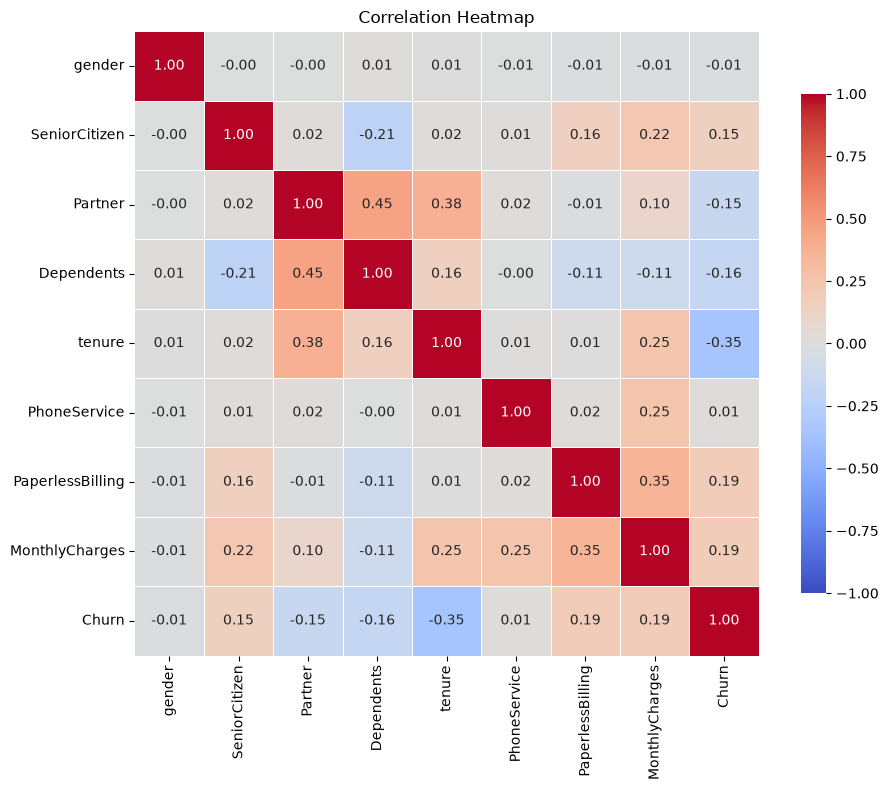

In [7]:
# Correlation heatmap

corr = telco.corr(numeric_only=True)

# Set up the figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(
    corr,
    annot=True,  # show correlation values
    fmt=".2f",  # 2 decimal places
    cmap="coolwarm",  # color scheme
    vmin=-1,
    vmax=1,  # fix color scale to correlation range
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

/var/folders/rp/gf132r1n5bj14p__kxdf2hrm0000gp/T/ipykernel_78171/3023687994.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


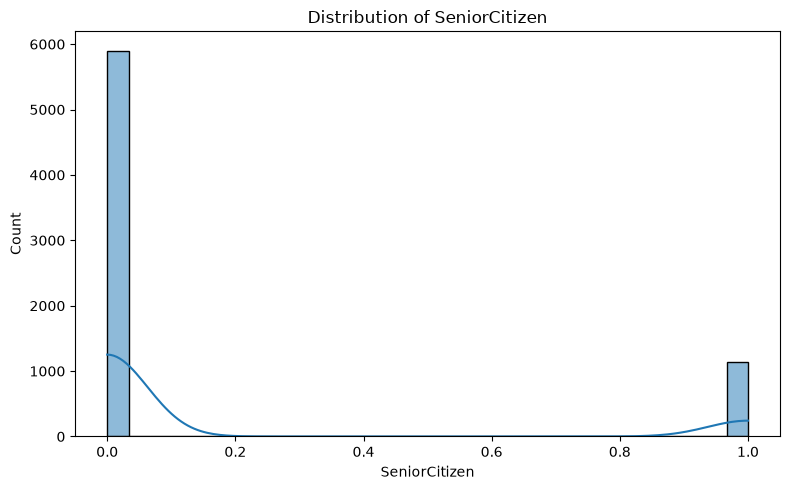

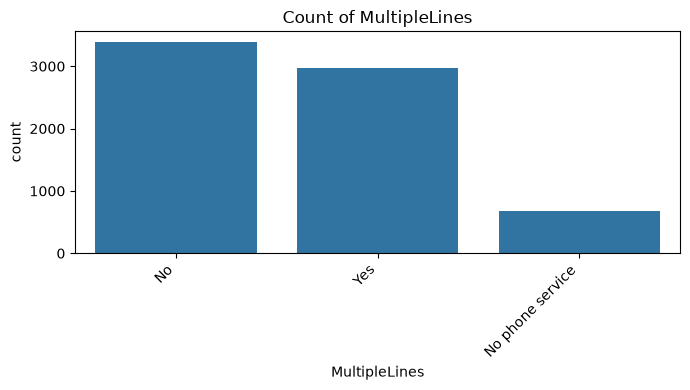

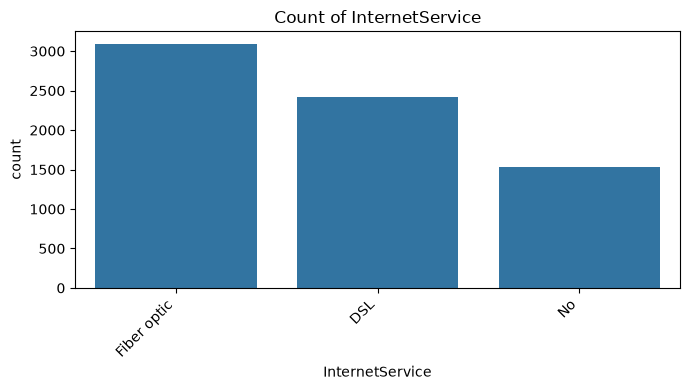

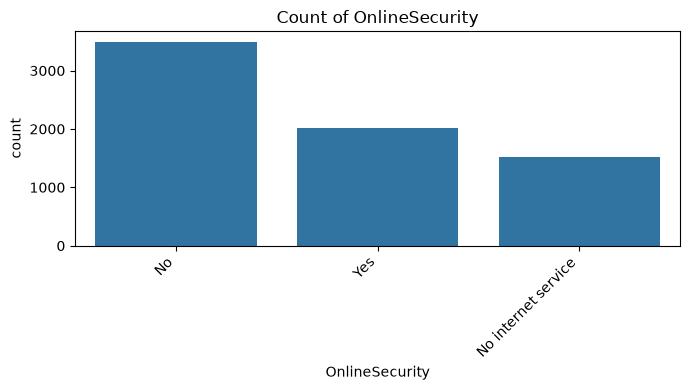

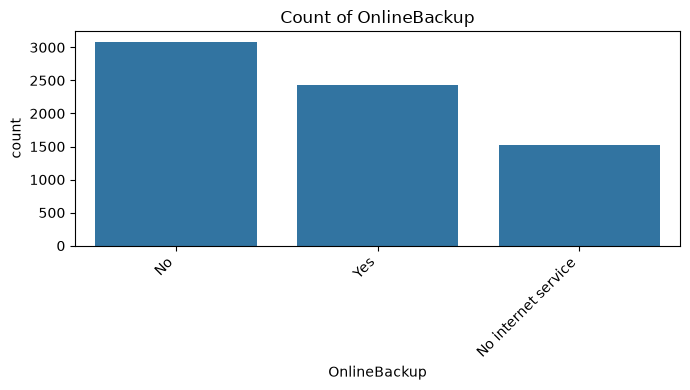

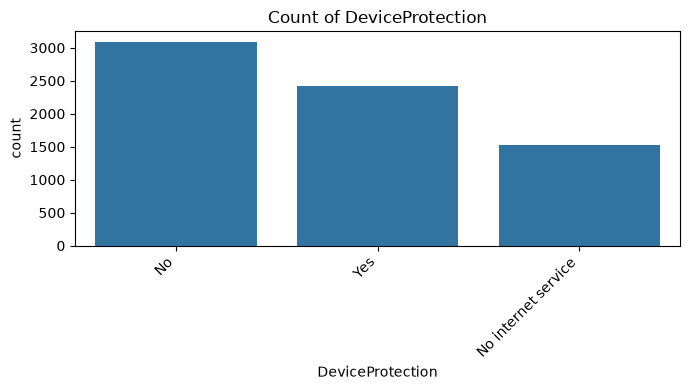

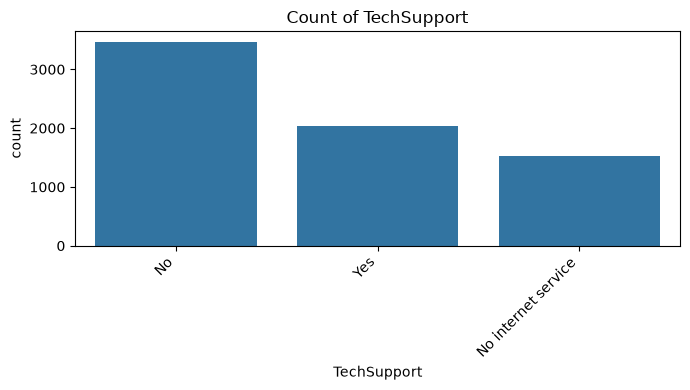

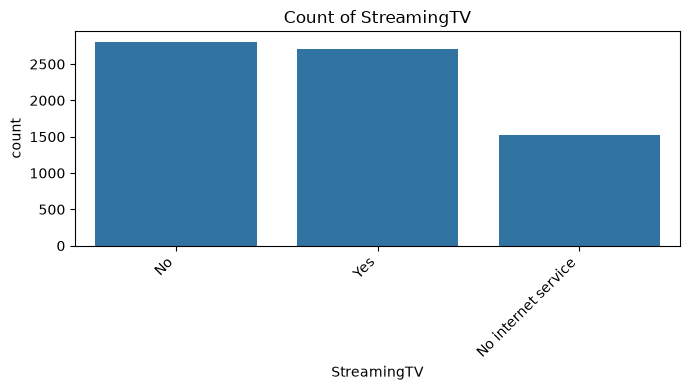

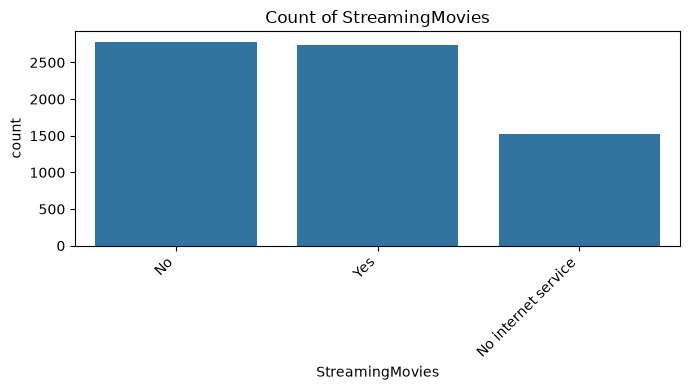

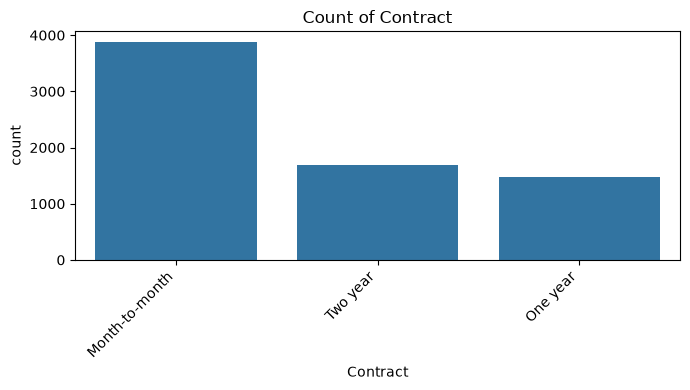

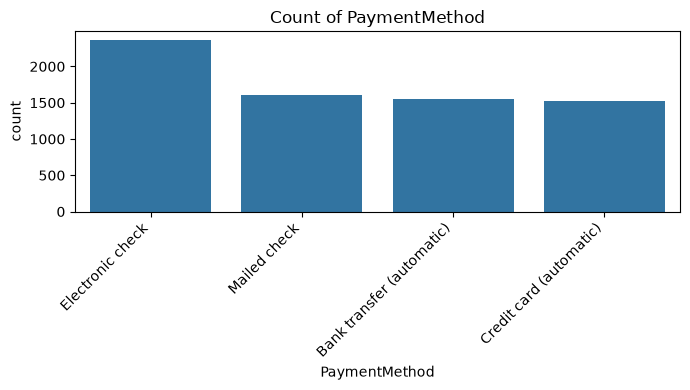

Skipping bar plots for high-cardinality columns: ['TotalCharges']
Consider grouping rare categories into 'Other' first.


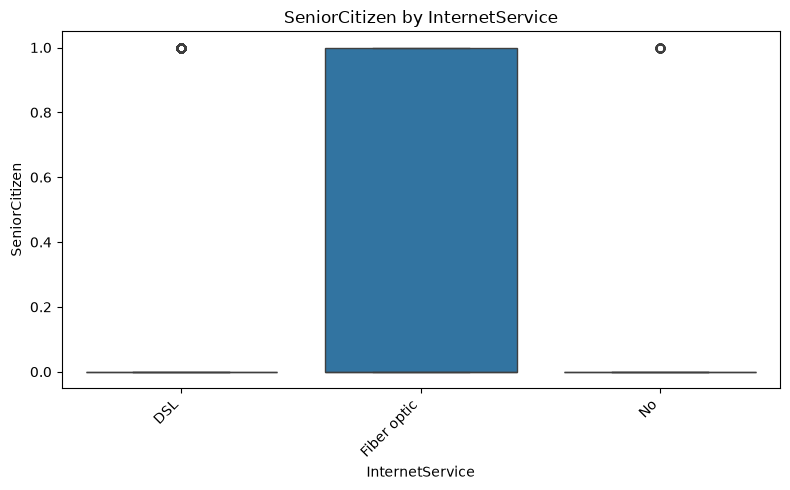

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df = telco

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Classify categorical columns by cardinality
binary_cols = [c for c in categorical_cols if df[c].nunique() == 2]
low_card_cols = [c for c in categorical_cols if 2 < df[c].nunique() <= 10]
high_card_cols = [c for c in categorical_cols if df[c].nunique() > 10]

# ---------------------------------------------------------
# 1. Numeric distributions — pick the numeric col with most spread
#    (highest coefficient of variation), since it's likely to show
#    the most interesting shape/skew
# ---------------------------------------------------------
if numeric_cols:
    cv = (df[numeric_cols].std() / df[numeric_cols].mean().abs()).sort_values(
        ascending=False
    )
    top_numeric = cv.index[0]

    plt.figure(figsize=(8, 5))
    sns.histplot(df[top_numeric], kde=True, bins=30)
    plt.title(f"Distribution of {top_numeric}")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 2. Categorical composition — bar chart of proportions for binary
#    cols (compact, shows imbalance at a glance); countplot for
#    low-cardinality cols; skip high-cardinality (not visualizable
#    as a bar chart without collapsing rare categories)
# ---------------------------------------------------------
if binary_cols:
    fig, axes = plt.subplots(1, len(binary_cols), figsize=(4 * len(binary_cols), 4))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, binary_cols):
        df[col].value_counts(normalize=True).plot(
            kind="bar", ax=ax, color=["#4C72B0", "#DD8452"]
        )
        ax.set_title(col)
        ax.set_ylabel("Proportion")
    plt.tight_layout()
    plt.show()

for col in low_card_cols:
    plt.figure(figsize=(7, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if high_card_cols:
    print(f"Skipping bar plots for high-cardinality columns: {high_card_cols}")
    print("Consider grouping rare categories into 'Other' first.")


# ---------------------------------------------------------
# 3. Numeric vs categorical — boxplot for low-cardinality, but
#    for binary use a violin (shows distribution shape, not just
#    a two-box comparison) paired with the numeric col most likely
#    to differ (highest variance ratio between groups)
# ---------------------------------------------------------
def best_split_col(numeric_col, candidate_cols):
    """Pick the categorical column that best separates the numeric variable,
    using between-group variance as a simple proxy."""
    best_col, best_score = None, -np.inf
    for cat_col in candidate_cols:
        group_means = df.groupby(cat_col)[numeric_col].mean()
        score = group_means.var()
        if score > best_score:
            best_col, best_score = cat_col, score
    return best_col


if numeric_cols and (binary_cols or low_card_cols):
    target_numeric = top_numeric
    candidates = binary_cols + low_card_cols
    split_col = best_split_col(target_numeric, candidates)

    plt.figure(figsize=(8, 5))
    if split_col in binary_cols:
        sns.violinplot(data=df, x=split_col, y=target_numeric)
    else:
        sns.boxplot(data=df, x=split_col, y=target_numeric)
    plt.title(f"{target_numeric} by {split_col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Assumption Checking

In [9]:
# **1. Appropriate Outcome Structure**
# Check that the dependent variable 'Churn' is binary (0 or 1).

print(telco_encoded["Churn"].unique())
telco_encoded["Churn"].value_counts()

[0 1]


Churn
0    5174
1    1869
Name: count, dtype: int64

In [10]:
# **2. Independence of Observations**
# This is usually a study design issue. Assuming rows represent unique customers, this assumption holds.

# **3. Linearity in the Logit**
# Check if continuous variables have a linear relationship with the log-odds of the outcome. We can use the Box-Tidwell test or visualize it. Continuous variables are 'tenure' and 'MonthlyCharges'.

continuous_vars = ["tenure", "MonthlyCharges"]

# Add log transformations of continuous variables
for var in continuous_vars:
    # Adding a small constant to avoid log(0) if there are any 0 values
    telco_encoded[f"{var}_log"] = telco_encoded[var] * np.log(telco_encoded[var] + 1e-6)

# Create a formula for logistic regression including interaction terms
features = continuous_vars + [f"{var}_log" for var in continuous_vars]
X_linearity = telco_encoded[features]
y_linearity = telco_encoded["Churn"]

# Fit the model to check significance of interaction terms
import statsmodels.api as sm

X_linearity = sm.add_constant(X_linearity)
logit_model = sm.Logit(y_linearity, X_linearity)
result = logit_model.fit()
print(result.summary())
# Look at the p-values for the interaction terms ('_log' columns).
# If they are significant (e.g., p < 0.05), the linearity assumption is violated.

# Clean up temporary columns
telco_encoded = telco_encoded.drop(columns=[f"{var}_log" for var in continuous_vars])

Optimization terminated successfully.
         Current function value: 0.450481
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7038
Method:                           MLE   Df Model:                            4
Date:                Mon, 31 Aug 2026   Pseudo R-squ.:                  0.2214
Time:                        13:27:34   Log-Likelihood:                -3172.7
converged:                       True   LL-Null:                       -4075.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.6425      0.288     -5.696      0.000      -2.208      -1.077
tenur

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# **4. Absence of Multicollinearity**
# Use Variance Inflation Factor (VIF) to check for multicollinearity among independent variables.


def calculate_vif(df, features):
    vif_data = pd.DataFrame()
    vif_data["feature"] = features
    vif_data["VIF"] = [
        variance_inflation_factor(df[features].values, i) for i in range(len(features))
    ]
    return vif_data


# Select features for the model (excluding the target 'Churn' and original categorical columns)
model_features = [
    col
    for col in telco_encoded.columns
    if col not in ["Churn"] + cols_to_encode + ["TotalCharges"]
]

# Handle potential missing values or infinite values before VIF
X_vif = telco_encoded[model_features].replace([np.inf, -np.inf], np.nan).dropna()
# Add a constant for VIF calculation
X_vif = sm.add_constant(X_vif)

vif_results = calculate_vif(X_vif, X_vif.columns)
print(vif_results)
# VIF values > 5 or 10 indicate high multicollinearity.

/var/folders/rp/gf132r1n5bj14p__kxdf2hrm0000gp/T/ipykernel_78171/2246117769.py:10: UserWarning: The design matrix is poorly conditioned (condition number=2.86e+33). VIF calculations may be numerically unstable.
  variance_inflation_factor(df[features].values, i) for i in range(len(features))
/Users/gauravlaw/Desktop/XAI/venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/gauravlaw/Desktop/XAI/venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/gauravlaw/Desktop/XAI/venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters 

                                    feature           VIF
0                                     const  1.000000e+00
1                                    gender  1.001910e+00
2                             SeniorCitizen  1.153343e+00
3                                   Partner  1.462490e+00
4                                Dependents  1.383731e+00
5                                    tenure  2.785141e+00
6                              PhoneService  1.000800e+15
7                          PaperlessBilling  1.208998e+00
8                            MonthlyCharges  8.626601e+02
9                          MultipleLines_No  1.000800e+15
10           MultipleLines_No phone service  1.000800e+15
11                        MultipleLines_Yes  1.000800e+15
12                      InternetService_DSL  1.000800e+15
13              InternetService_Fiber optic  1.000800e+15
14                       InternetService_No  1.000800e+15
15                        OnlineSecurity_No  1.000800e+15
16       Onlin

/Users/gauravlaw/Desktop/XAI/venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/gauravlaw/Desktop/XAI/venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/gauravlaw/Desktop/XAI/venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/gauravlaw/Desktop/XAI/venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_s

In [15]:
# **5. Lack of Strongly Influential Outliers**
# Cook's distance can be used, but standard scaling and robust models often mitigate this.


# **6. Sufficient Sample Size**
# Check if there are enough cases for the minority class (Churn=1).

min_cases = telco_encoded["Churn"].value_counts().min()
num_features = len(model_features)
print(f"Number of features: {num_features}")
print(f"Number of minority class cases: {min_cases}")
print(f"Ratio: {min_cases / num_features:.2f} cases per feature (Aim for >10-15)")

Number of features: 39
Number of minority class cases: 1869
Ratio: 47.92 cases per feature (Aim for >10-15)


## Model

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    log_loss,
    brier_score_loss,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ==========================================
# 1. LOAD DATA & INITIAL EDA
# ==========================================
telco = pd.read_csv("/Users/gauravlaw/Desktop/XAI/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Drop customerID (not a predictive feature)
telco = telco.drop(columns=["customerID"])

# Handle 'TotalCharges': convert blank spaces to NaN, then fill with 0 and cast to float
telco["TotalCharges"] = pd.to_numeric(
    telco["TotalCharges"].replace(" ", np.nan)
).fillna(0)

# ==========================================
# 2. ENCODING & PREPROCESSING
# ==========================================
# Find categorical columns with exactly 2 unique values
binary_cols = [
    col
    for col in telco.select_dtypes(include=["object", "category"]).columns
    if telco[col].nunique(dropna=True) == 2
]

# Convert each binary column to 0/1 (including 'Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling')
for col in binary_cols:
    categories = sorted(telco[col].dropna().unique())
    mapping = {categories[0]: 0, categories[1]: 1}
    telco[col] = telco[col].map(mapping)

# Identify multi-class categorical columns to one-hot encode
cols_to_encode = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

# One-hot encode the selected columns
telco_encoded = pd.get_dummies(
    telco, columns=cols_to_encode, dtype=int, prefix=cols_to_encode
)

# ==========================================
# 3. MODEL PREPARATION
# ==========================================
# Define features (X) and target (y)
X = telco_encoded.drop(columns=["Churn"])
y = telco_encoded["Churn"]

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the continuous/encoded features
# (Important for regularized algorithms like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 4. LOGISTIC REGRESSION TRAINING
# ==========================================
# Initialize and Train the Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ==========================================
# 5. EVALUATION
# ==========================================
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
logloss = log_loss(y_test, y_prob)
brier_score = brier_score_loss(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Log Loss: {logloss:.4f}")
print(f"Brier Score: {brier_score:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

feature_names = X.columns
coefficients = model.coef_[0]

# Create a DataFrame to view the Features, Coefficients, and Odds Ratios
results_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Odds_Ratio": np.exp(coefficients),  # Exponentiate to get the odds ratio
    }
)

# Sort by Odds Ratio in descending order to see top churn drivers first
results_df = results_df.sort_values(by="Odds_Ratio", ascending=False).reset_index(
    drop=True
)

print("--- Top 5 Drivers INCREASING Churn Risk ---")
print(results_df.head(5).to_string())

print("\n--- Top 5 Drivers DECREASING Churn Risk ---")
print(results_df.tail(5).to_string())

Accuracy: 0.8204
ROC AUC: 0.8621
Log Loss: 0.3977
Brier Score: 0.1289

Confusion Matrix:
[[933 103]
 [150 223]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

--- Top 5 Drivers INCREASING Churn Risk ---
                       Feature  Coefficient  Odds_Ratio
0                 TotalCharges     0.657428    1.929822
1  InternetService_Fiber optic     0.349267    1.418028
2      Contract_Month-to-month     0.308275    1.361075
3             PaperlessBilling     0.164030    1.178250
4          StreamingMovies_Yes     0.158953    1.172282

--- Top 5 Drivers DECREASING Churn Risk ---
                             Feature  Coefficient  Odds_Ratio
35  OnlineBackup_No internet service    -0.093781 

/var/folders/rp/gf132r1n5bj14p__kxdf2hrm0000gp/T/ipykernel_78171/431052586.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in telco.select_dtypes(include=["object", "category"]).columns


# Interpretations

A one-unit change in total charges corresponds to a 1.92 multiplicative odds change in churn. This tell us that total charges may have one of the highest impacts on churn in general. On the other hand, a one-year change in tenure corresponds to a 0.25 multiplicative odds change in in churn, actually decreasing the number of customers that may return to Telco.

# Limitations

One limitation of using logistic regression for churn would be inability to automatically capture complex, non-linear interactions between features. For example, because logistic uses a linear decision boundary, there is little interaction effects present, as each feature affects log-odds independently and additively.